# 02 — What the feature matrix holds, before any modelling decision

## What this notebook reads

The engineered matrix, and it says which one. `var/data/processed/features.parquet` when
notebook 01 has been run on the Home Credit tables; the scoring holdout otherwise, which is
the same columns on a tenth of the rows. Neither is redistributable, so neither is in this
repository, and the cell below prints the frame it found.

## What it establishes

- how imbalanced the target is
- what kinds of variable the matrix holds
- how much is missing, and where
- whether the joins multiplied any row
- which variables carry extreme values
- which ones correlate with the target at all

## One methodological note

Feature engineering already happened upstream, so nothing here changes the matrix. In
particular **missing values are not dropped**: they go to median imputation inside the
training pipeline, fitted on the training fold, so that nothing about the validation fold
reaches the transformer.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from credexp.config import settings
from credexp.data.io import load_parquet

In [2]:
from credexp.utils import HOLDOUT_PATH, PROCESSED_DIR

FEATURES = PROCESSED_DIR / "features.parquet"
source = FEATURES if FEATURES.is_file() else HOLDOUT_PATH
if not source.is_file():
    raise SystemExit(
        f"neither {FEATURES} nor {HOLDOUT_PATH} is here — "
        "run scripts/build_features.py on the Home Credit tables first"
    )

df = load_parquet(source)
print(f"read {source.relative_to(settings.project_root)}")
df.shape

{"ts": "2026-09-15T16:45:15Z", "level": "INFO", "name": "credexp.data.io", "msg": "load_parquet path=var/data/processed/api_holdout.parquet"}


read var\data\processed\api_holdout.parquet


(30751, 797)

In [3]:
assert "TARGET" in df.columns, "TARGET column is missing!"

# Home Credit ships a labelled table and an unlabelled one, concatenated by notebook 01 so
# that one encoding pass covers both. A row whose target is missing is a row nobody can
# score against, and it is separated here rather than in the training script.
labelled = df[df["TARGET"].notna()].copy()
unlabelled = df[df["TARGET"].isna()].copy()

df_train = labelled
df_test = unlabelled
labelled.shape, unlabelled.shape

((30751, 797), (0, 797))

## 1) How imbalanced is the target

Default is the minority class in Home Credit, and by how much decides which metrics are worth reading later — accuracy will not be one of them.

Counts per class and the default rate, printed rather than plotted: two values make a table, not a chart.

In [4]:
y = df_train["TARGET"].astype(int)

counts = y.value_counts().sort_index()
rate = y.mean()

counts, rate

(TARGET
 0    28268
 1     2483
 Name: count, dtype: int64,
 0.08074534161490683)

## 2) What kinds of variable

The aggregation approach produces mostly numeric columns, coming from three places: the original application fields, one-hot encoding of the categorical ones, and per-table statistical aggregates.

The dtype breakdown confirms it.

In [5]:
df_train.dtypes.value_counts()

float64    605
bool       133
int64       42
object      16
int32        1
Name: count, dtype: int64

## 3) Missing values

The missing rate per column, the worst-affected columns, and a `missingno` view on a sample.

**Nothing is dropped here.** Missing values go to median imputation inside the training pipeline, so that the same rule applies at training and at serving. A column removed in a notebook is a rule that exists nowhere the API can see.

In [6]:
missing_rate = df_train.isna().mean().sort_values(ascending=False)
missing_rate.head(20)

REFUSED_AMT_DOWN_PAYMENT_MAX         0.852428
REFUSED_RATE_DOWN_PAYMENT_MAX        0.852428
REFUSED_AMT_DOWN_PAYMENT_MIN         0.852428
REFUSED_AMT_DOWN_PAYMENT_MEAN        0.852428
REFUSED_RATE_DOWN_PAYMENT_MIN        0.852428
REFUSED_RATE_DOWN_PAYMENT_MEAN       0.852428
REFUSED_APP_CREDIT_PERC_VAR          0.838607
CC_CNT_DRAWINGS_ATM_CURRENT_VAR      0.801925
CC_AMT_DRAWINGS_POS_CURRENT_VAR      0.801925
CC_AMT_DRAWINGS_ATM_CURRENT_VAR      0.801925
CC_AMT_DRAWINGS_OTHER_CURRENT_VAR    0.801925
CC_CNT_DRAWINGS_OTHER_CURRENT_VAR    0.801925
CC_CNT_DRAWINGS_POS_CURRENT_VAR      0.801925
CC_AMT_PAYMENT_CURRENT_VAR           0.801730
ACTIVE_AMT_ANNUITY_MEAN              0.801535
ACTIVE_AMT_ANNUITY_MAX               0.801535
CC_CNT_DRAWINGS_POS_CURRENT_MEAN     0.800559
CC_CNT_DRAWINGS_ATM_CURRENT_MIN      0.800559
CC_CNT_DRAWINGS_ATM_CURRENT_MAX      0.800559
CC_CNT_DRAWINGS_ATM_CURRENT_MEAN     0.800559
dtype: float64

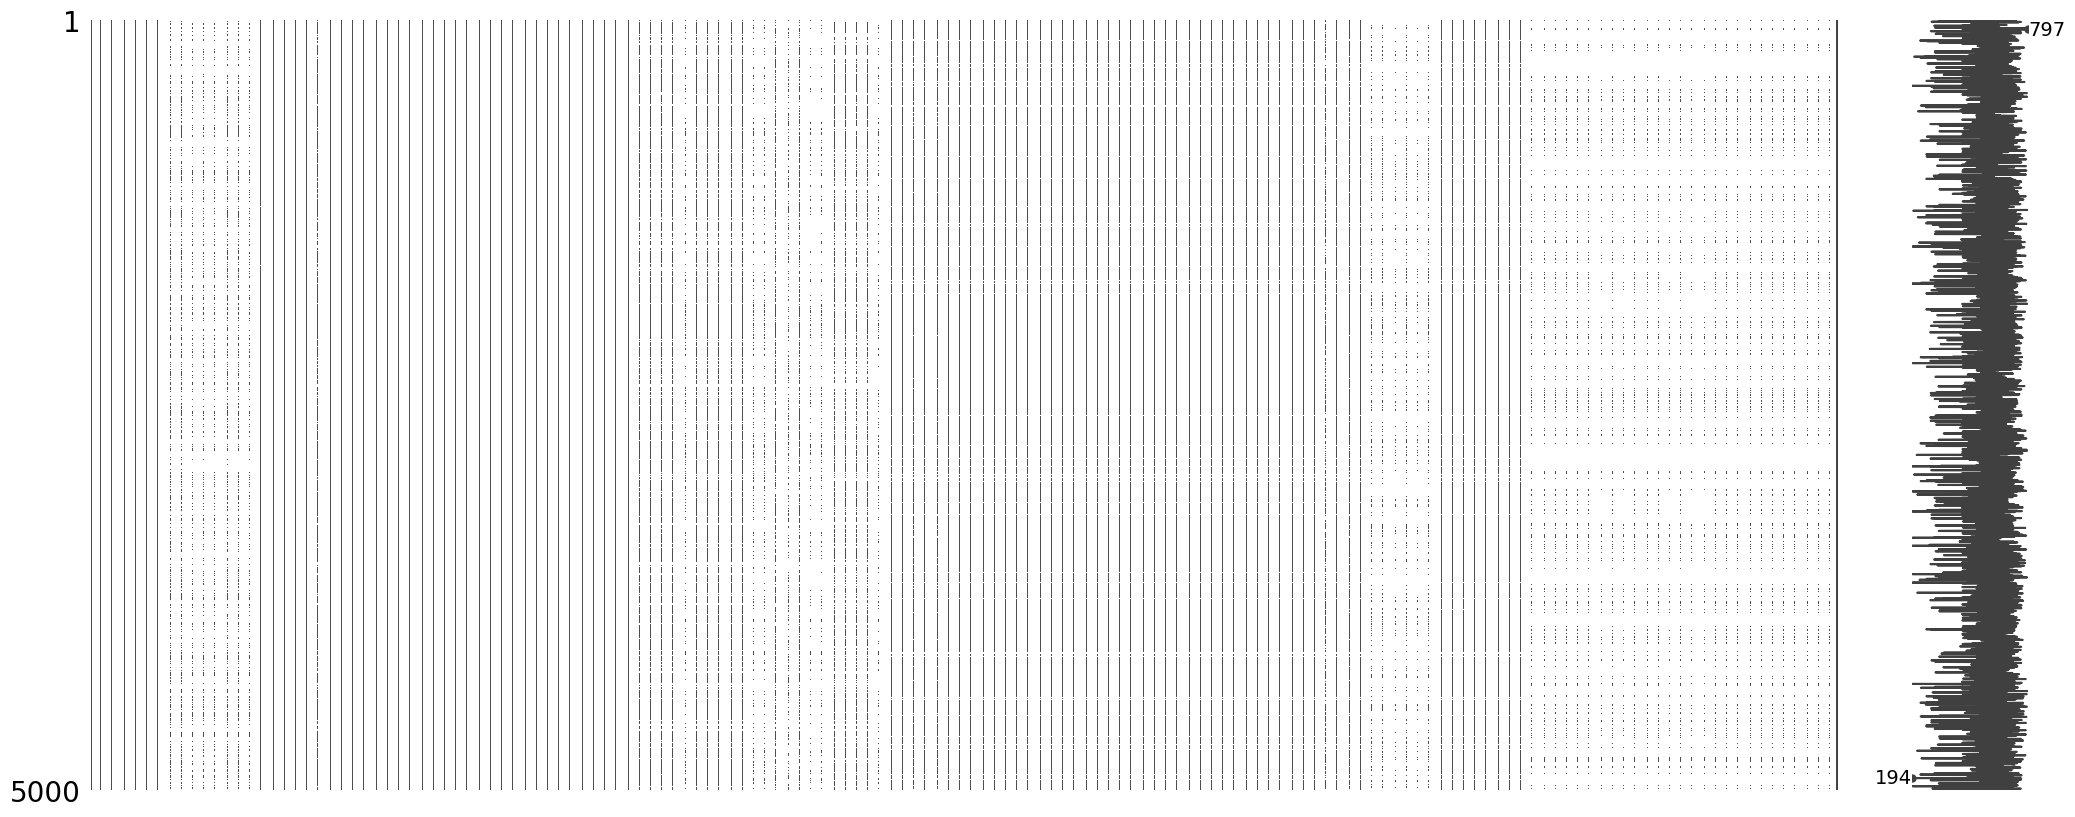

In [7]:
sample = df_train.sample(n=min(5000, len(df_train)), random_state=settings.random_state)
msno.matrix(sample)
plt.show()

In [8]:
high_missing = missing_rate[missing_rate > 0.8]
len(high_missing), high_missing.head(10)

(37,
 REFUSED_AMT_DOWN_PAYMENT_MAX       0.852428
 REFUSED_RATE_DOWN_PAYMENT_MAX      0.852428
 REFUSED_AMT_DOWN_PAYMENT_MIN       0.852428
 REFUSED_AMT_DOWN_PAYMENT_MEAN      0.852428
 REFUSED_RATE_DOWN_PAYMENT_MIN      0.852428
 REFUSED_RATE_DOWN_PAYMENT_MEAN     0.852428
 REFUSED_APP_CREDIT_PERC_VAR        0.838607
 CC_CNT_DRAWINGS_ATM_CURRENT_VAR    0.801925
 CC_AMT_DRAWINGS_POS_CURRENT_VAR    0.801925
 CC_AMT_DRAWINGS_ATM_CURRENT_VAR    0.801925
 dtype: float64)

## 4) Duplicates

Two different questions:
1. Duplicate `SK_ID_CURR` keys — there should be **one row per customer**, and more than one would mean the joins multiplied rows.
2. Fully identical rows — rarer, and worth ruling out.

Starting with the key.

In [9]:
key = "SK_ID_CURR"

n_total = len(df_train)
n_unique = df_train[key].nunique()
n_total, n_unique, n_total - n_unique

(30751, 30751, 0)

In [10]:
dup_keys = df_train[key].value_counts()
dup_keys = dup_keys[dup_keys > 1]
dup_keys.head()

Series([], Name: count, dtype: int64)

In [11]:
exact_dups = df_train.duplicated().sum()
exact_dups

0

## 5) Extreme values

Financial variables are often heavily skewed, and a few of them here are. The check is deliberately simple:
- the 1% and 99% quantiles
- an IQR pass on a handful of key variables
- a boxplot and a histogram

What it is for: finding the variables that need a transform, or that need watching in the pipeline.

In [12]:
candidate_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH", "DAYS_EMPLOYED"]
candidate_cols = [c for c in candidate_cols if c in df_train.columns]

df_train[candidate_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
AMT_INCOME_TOTAL,30751.0,167936.569512,97138.368669,25650.0,45000.00,67500.0,148500.0,332550.00,450000.0,3375000.0
AMT_CREDIT,30751.0,602806.000846,403602.337746,45000.0,76410.00,139306.5,521280.0,1350000.00,1888425.0,3375000.0
AMT_ANNUITY,30751.0,27131.311730,14332.107657,1980.0,6174.00,9000.0,25033.5,53453.25,68692.5,225000.0
DAYS_BIRTH,30751.0,-16114.708725,4356.723085,-25196.0,-24439.50,-23235.5,-15870.0,-9474.00,-8294.0,-7676.0
DAYS_EMPLOYED,25127.0,-2404.776734,2362.787568,-16678.0,-11448.96,-7341.7,-1662.0,-207.00,-112.0,0.0


In [13]:
def iqr_outlier_rate(s: pd.Series) -> float:
    s = s.dropna()
    if s.empty:
        return 0.0
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return float(((s < lo) | (s > hi)).mean())


outlier_rates = {c: iqr_outlier_rate(df_train[c]) for c in candidate_cols}
pd.Series(outlier_rates).sort_values(ascending=False)

DAYS_EMPLOYED       0.058901
AMT_INCOME_TOTAL    0.043999
AMT_ANNUITY         0.024097
AMT_CREDIT          0.022731
DAYS_BIRTH          0.000000
dtype: float64

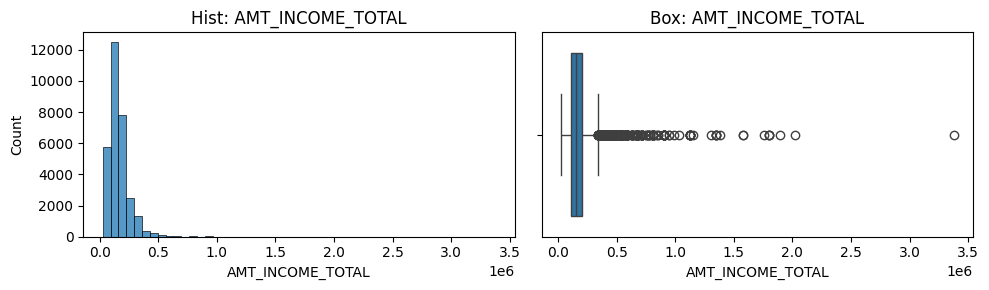

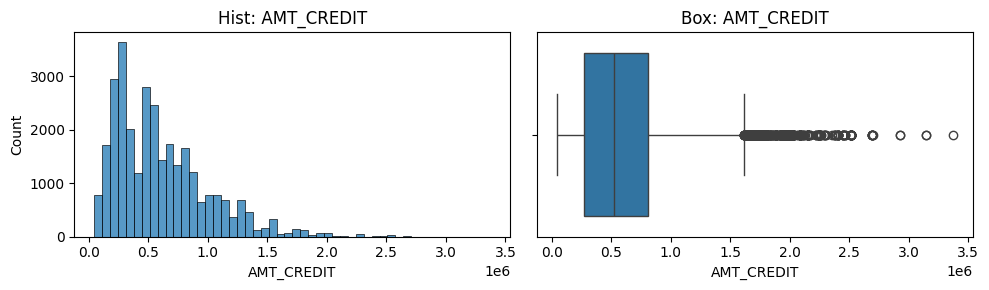

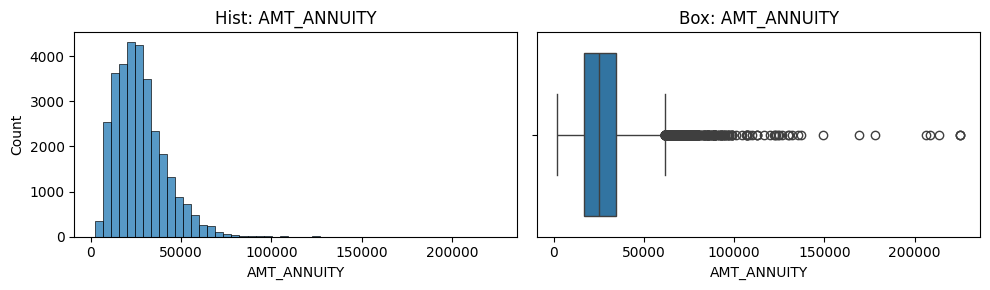

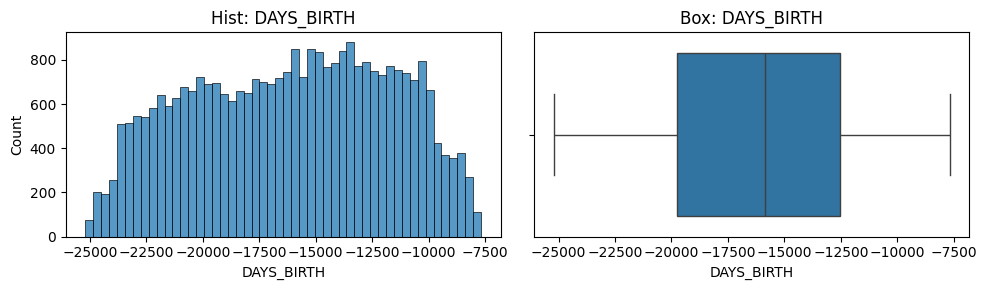

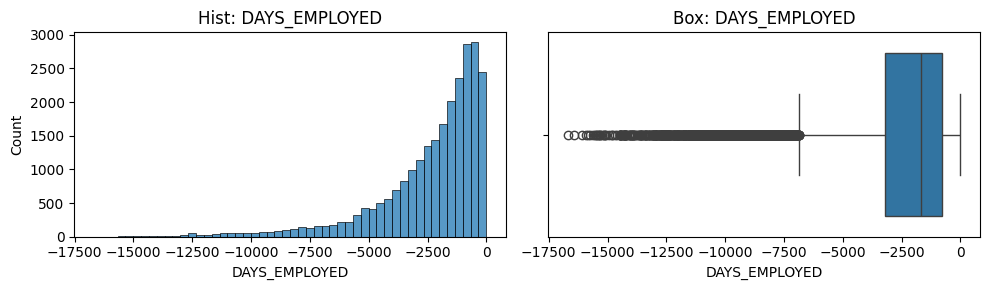

In [14]:
for c in candidate_cols:
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df_train[c].dropna(), bins=50, ax=ax[0])
    ax[0].set_title(f"Hist: {c}")

    sns.boxplot(x=df_train[c].dropna(), ax=ax[1])
    ax[1].set_title(f"Box: {c}")

    plt.tight_layout()
    plt.show()

## 6) Correlations, on a subset

A heatmap over seven hundred features is unreadable, so it is not drawn. Instead:
1. correlations against `TARGET`, with the strongest shown
2. a heatmap restricted to those

> Correlation is not causation, and a linear correlation of zero does not mean a variable is useless to a tree model. This section suggests where to look; it decides nothing.

In [15]:
train_numeric = df_train.select_dtypes(include=[np.number]).copy()
corr_with_target = train_numeric.corr()["TARGET"].drop("TARGET").sort_values()

top_neg = corr_with_target.head(10)
top_pos = corr_with_target.tail(10)

top_neg, top_pos

(EXT_SOURCE_3                         -0.178564
 EXT_SOURCE_2                         -0.165528
 EXT_SOURCE_1                         -0.160588
 BURO_MONTHS_BALANCE_SIZE_MEAN        -0.086796
 BURO_CREDIT_ACTIVE_Closed_MEAN       -0.082583
 CC_COUNT                             -0.078046
 CC_NAME_CONTRACT_STATUS_Active_SUM   -0.076319
 CC_MONTHS_BALANCE_VAR                -0.074195
 ACTIVE_MONTHS_BALANCE_SIZE_MEAN      -0.072558
 PREV_CODE_REJECT_REASON_XAP_MEAN     -0.070946
 Name: TARGET, dtype: float64,
 POS_NAME_CONTRACT_STATUS_XNA_MEAN       NaN
 POS_NAME_CONTRACT_STATUS_nan_MEAN       NaN
 CC_SK_DPD_MIN                           NaN
 CC_SK_DPD_DEF_MIN                       NaN
 CC_NAME_CONTRACT_STATUS_Approved_MEAN   NaN
 CC_NAME_CONTRACT_STATUS_Approved_SUM    NaN
 CC_NAME_CONTRACT_STATUS_Approved_VAR    NaN
 CC_NAME_CONTRACT_STATUS_nan_MEAN        NaN
 CC_NAME_CONTRACT_STATUS_nan_SUM         NaN
 CC_NAME_CONTRACT_STATUS_nan_VAR         NaN
 Name: TARGET, dtype: float64)

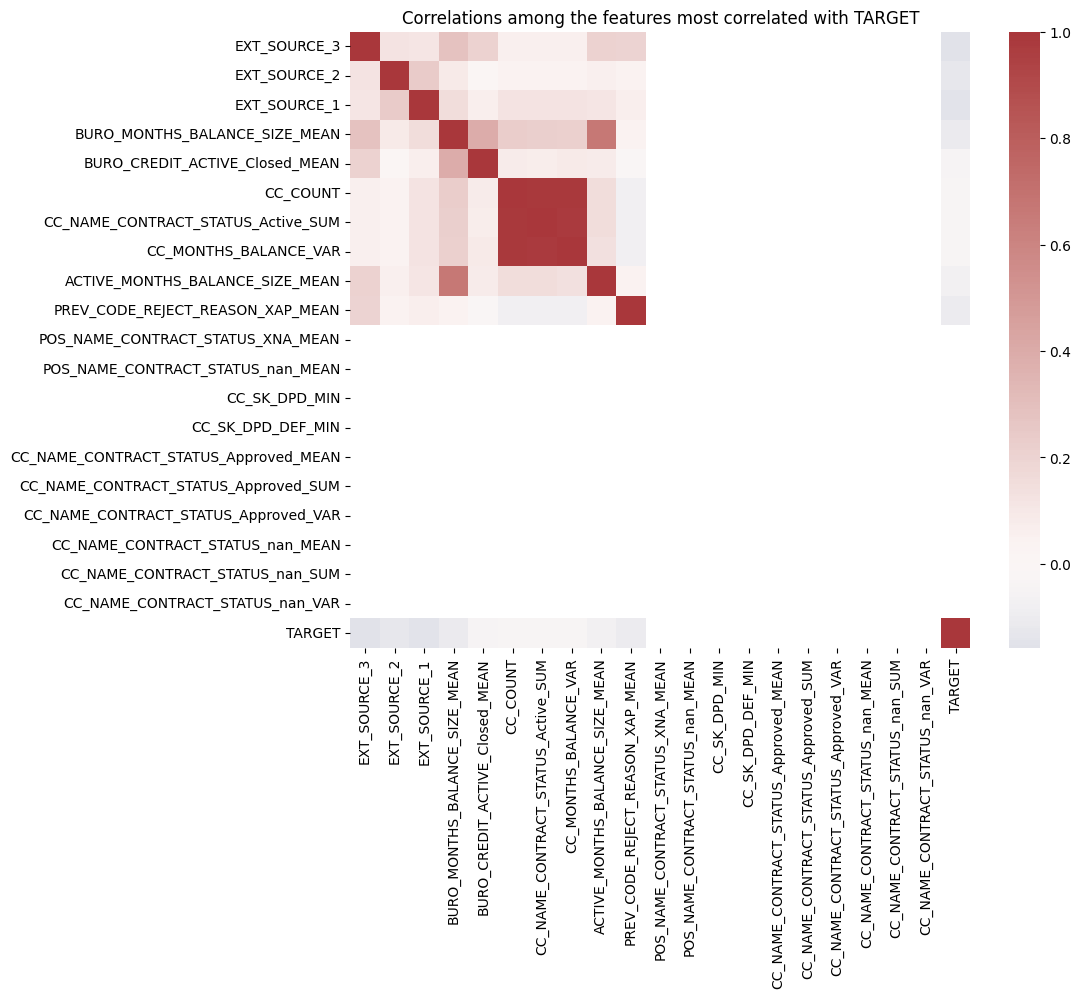

In [16]:
top_features = list(top_neg.index) + list(top_pos.index) + ["TARGET"]
subset = train_numeric[top_features].dropna()

plt.figure(figsize=(10, 8))
sns.heatmap(subset.corr(), center=0, cmap="vlag", annot=False)
plt.title("Correlations among the features most correlated with TARGET")
plt.show()

## 7) The reference the drift monitor compares against

A sample of this matrix is what drift monitoring compares production traffic against, so it
has to be fixed once and kept: recomputing it later would compare production against itself.

It is written by `scripts/build_drift_reference.py`, not here. A notebook that writes an
artefact is an artefact whose provenance no manifest can record, and this one is read by a
monitoring job months after anyone last opened the notebook.


## What this changes downstream

- `TARGET` is strongly imbalanced, so the model needs an explicit imbalance strategy and a metric that survives it.
- The matrix is almost entirely numeric, which keeps the preprocessing short.
- Missing values are common on some features and are handled by **median imputation inside the pipeline**, never here.
- `SK_ID_CURR` is unique, so the joins did not multiply rows.
- A few variables are widely dispersed — worth remembering when the probability scale and the business threshold are chosen.
- The correlations point at candidates. They do not rank features, and nothing here substitutes for measuring a model.

Next: training, with MLflow tracking (notebook 03).